# 03  Exploratory Data Analysis (EDA)

## 1. Purpose

This notebook performs exploratory data analysis on the cleaned and
analysis-ready Online Retail II dataset.

The purpose of the EDA is to:

1. Understand customer purchasing behaviour.
2. Examine transaction, product, time and geographic patterns.
3. Identify distributions, trends, relationships and potential outliers.
4. Examine purchasing frequency and inactivity patterns relevant to
   customer retention.
5. Determine which variables and behavioural characteristics should
   be carried forward into customer-level analysis, RFM segmentation
   and subsequent predictive modelling.

The EDA follows the CRISP-DM methodology and builds upon the
Data Understanding and Data Preparation stages completed previously.

The analysis is structured around six analytical views:

- Transaction
- Customer
- Product
- Time
- Country
- Customer retention behaviour

EDA findings will be used to inform feature engineering, modelling
decisions and Power BI dashboard development.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [105]:
# ============================================================
# LOAD PROCESSED DATA
# ============================================================

df = pd.read_csv(
    "../data/processed/clean_transactions.csv",
    dtype={"Invoice": "string"}
)

# Standardise key fields
df["Invoice"] = df["Invoice"].str.strip()
df["StockCode"] = df["StockCode"].astype(str).str.strip()
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique invoices:", df["Invoice"].nunique())
print("Unique customers:", df["Customer ID"].nunique())

Rows: 1007913
Columns: 17
Unique invoices: 40077
Unique customers: 5878


In [106]:
print("Remaining cancellations:", df["IsCancellation"].sum())
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Non-positive prices:", (df["Price"] <= 0).sum())
print("Missing dates:", df["InvoiceDate"].isna().sum())

print("\nUnique invoices:", df["Invoice"].nunique())
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())

Remaining cancellations: 0
Negative quantities: 0
Non-positive prices: 0
Missing dates: 0

Unique invoices: 40077
Unique customers: 5878
Unique products: 4916
Countries: 43


In [107]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,Revenue,Year,Month,MonthName,Quarter,Day,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,False,83.40,2009,12,December,4,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00,2009,12,December,4,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00,2009,12,December,4,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,False,100.80,2009,12,December,4,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,False,30.00,2009,12,December,4,1,Tuesday,7


In [108]:
df.shape

(1007913, 17)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 17 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   Invoice         1007913 non-null  string        
 1   StockCode       1007913 non-null  object        
 2   Description     1007913 non-null  object        
 3   Quantity        1007913 non-null  int64         
 4   InvoiceDate     1007913 non-null  datetime64[ns]
 5   Price           1007913 non-null  float64       
 6   Customer ID     779425 non-null   float64       
 7   Country         1007913 non-null  object        
 8   IsCancellation  1007913 non-null  bool          
 9   Revenue         1007913 non-null  float64       
 10  Year            1007913 non-null  int64         
 11  Month           1007913 non-null  int64         
 12  MonthName       1007913 non-null  object        
 13  Quarter         1007913 non-null  int64         
 14  Day             10

In [110]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Rows: 1007913
Columns: 17

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'IsCancellation', 'Revenue', 'Year', 'Month', 'MonthName', 'Quarter', 'Day', 'DayOfWeek', 'Hour']


In [111]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,Revenue,Year,Month,MonthName,Quarter,Day,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,False,83.40,2009,12,December,4,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00,2009,12,December,4,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00,2009,12,December,4,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,False,100.80,2009,12,December,4,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,False,30.00,2009,12,December,4,1,Tuesday,7


In [112]:
missing = (
    df.isna()
      .sum()
      .to_frame("Missing Values")
)

missing["Missing %"] = (
    missing["Missing Values"] / len(df) * 100
)

missing.sort_values("Missing %", ascending=False)

,Missing Values,Missing %
Customer ID,228488,22.67
Invoice,0,0.00
Revenue,0,0.00
DayOfWeek,0,0.00
Day,0,0.00
Quarter,0,0.00
MonthName,0,0.00
Month,0,0.00
Year,0,0.00
IsCancellation,0,0.00


In [113]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [114]:
df.dtypes

Invoice           string[python]
StockCode                 object
Description               object
Quantity                   int64
InvoiceDate       datetime64[ns]
Price                    float64
Customer ID              float64
Country                   object
IsCancellation              bool
Revenue                  float64
Year                       int64
Month                      int64
MonthName                 object
Quarter                    int64
Day                        int64
DayOfWeek                 object
Hour                       int64
dtype: object

In [115]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,"1,007,913.00",11.12,1.00,1.00,4.00,12.00,"80,995.00",128.47
InvoiceDate,1007913,2011-01-04 10:34:18.759594752,2009-12-01 07:45:00,2010-07-06 11:21:00,2010-12-09 15:29:00,2011-07-28 12:29:00,2011-12-09 12:50:00,NaN
Price,"1,007,913.00",4.07,0.00,1.25,2.10,4.13,"25,111.09",50.43
Customer ID,"779,425.00","15,320.36","12,346.00","13,971.00","15,247.00","16,794.00","18,287.00","1,695.69"
Revenue,"1,007,913.00",20.32,0.00,4.13,10.08,17.70,"168,469.60",205.72
Year,"1,007,913.00","2,010.44","2,009.00","2,010.00","2,010.00","2,011.00","2,011.00",0.58
Month,"1,007,913.00",7.40,1.00,4.00,8.00,11.00,12.00,3.50
Quarter,"1,007,913.00",2.79,1.00,2.00,3.00,4.00,4.00,1.14
Day,"1,007,913.00",15.35,1.00,8.00,15.00,23.00,31.00,8.64
Hour,"1,007,913.00",13.02,6.00,11.00,13.00,15.00,20.00,2.43


In [116]:
transaction_kpis = {
    "Transaction lines": len(df),
    "Unique invoices": df["Invoice"].nunique(),
    "Unique customers": df["Customer ID"].nunique(),
    "Unique products": df["StockCode"].nunique(),
    "Countries": df["Country"].nunique(),
    "Total quantity": df["Quantity"].sum(),
    "Total revenue": df["Revenue"].sum()
}

pd.Series(transaction_kpis)

Transaction lines    1,007,913.00
Unique invoices         40,077.00
Unique customers         5,878.00
Unique products          4,916.00
Countries                   43.00
Total quantity      11,205,148.00
Total revenue       20,476,260.45
dtype: float64

In [117]:
df["Quantity"].describe()

count   1,007,913.00
mean           11.12
std           128.47
min             1.00
25%             1.00
50%             4.00
75%            12.00
max        80,995.00
Name: Quantity, dtype: float64

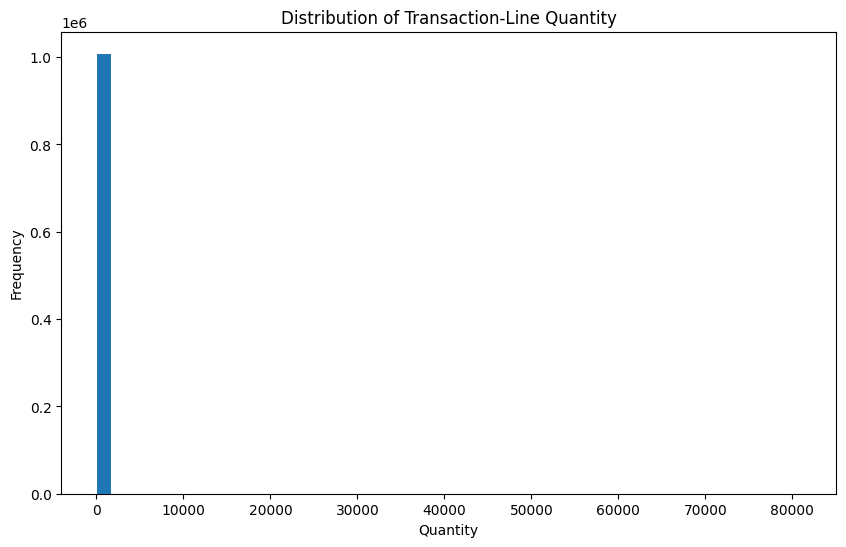

In [118]:
plt.figure(figsize=(10, 6))

plt.hist(df["Quantity"], bins=50)

plt.title("Distribution of Transaction-Line Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

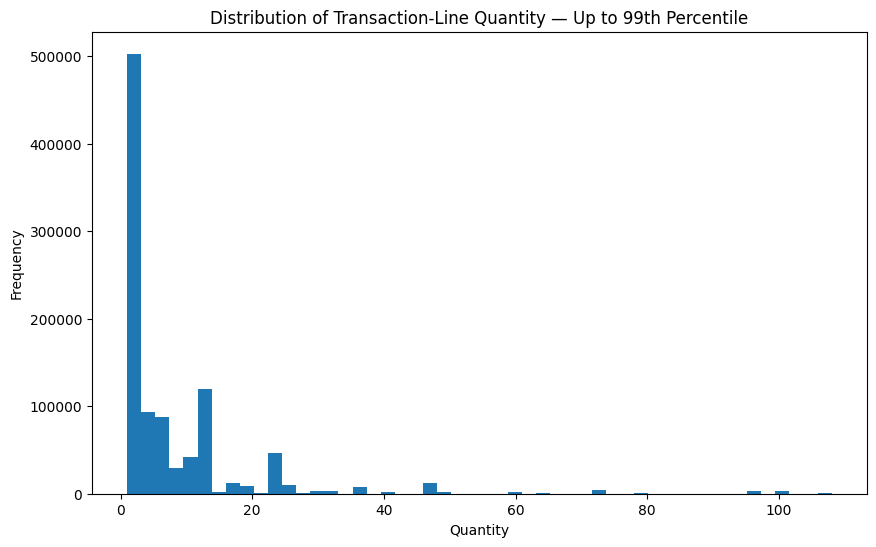

In [119]:
plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df["Quantity"] <= df["Quantity"].quantile(0.99), "Quantity"],
    bins=50
)

plt.title("Distribution of Transaction-Line Quantity — Up to 99th Percentile")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

In [120]:
df["Revenue"].describe()

count   1,007,913.00
mean           20.32
std           205.72
min             0.00
25%             4.13
50%            10.08
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64

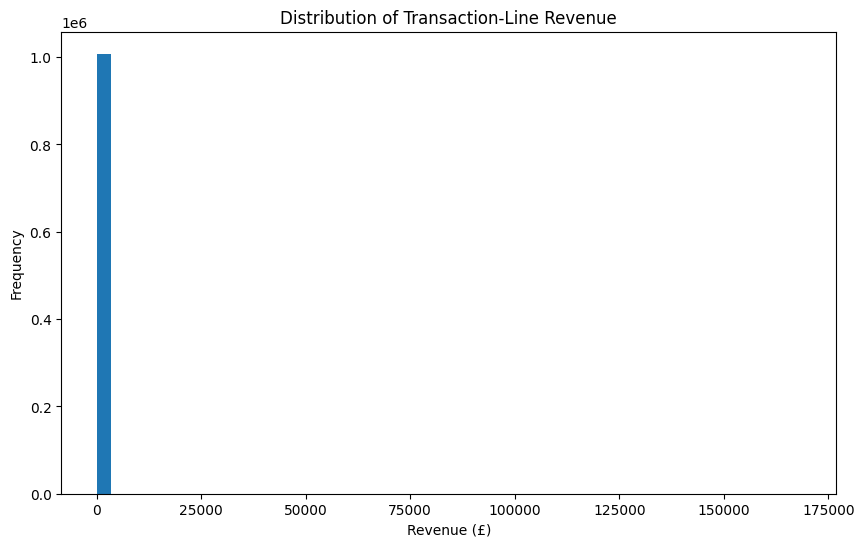

In [121]:
plt.figure(figsize=(10, 6))

plt.hist(df["Revenue"], bins=50)

plt.title("Distribution of Transaction-Line Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Frequency")

plt.show()

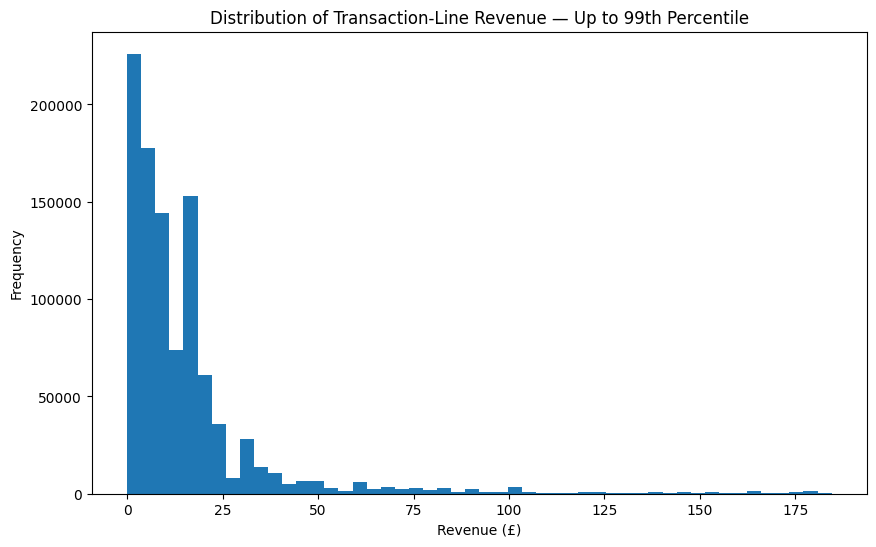

In [122]:
plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df["Revenue"] <= df["Revenue"].quantile(0.99), "Revenue"],
    bins=50
)

plt.title("Distribution of Transaction-Line Revenue — Up to 99th Percentile")
plt.xlabel("Revenue (£)")
plt.ylabel("Frequency")

plt.show()

In [123]:
# ============================================================
# CREATE INVOICE-LEVEL ANALYTICAL TABLE
# ============================================================

invoice_df = (
    df.groupby("Invoice", as_index=False)
      .agg(
          InvoiceDate=("InvoiceDate", "min"),
          CustomerID=("Customer ID", "first"),
          Country=("Country", "first"),
          Quantity=("Quantity", "sum"),
          Revenue=("Revenue", "sum"),
          UniqueProducts=("StockCode", "nunique"),
          LineItems=("StockCode", "size")
      )
)

print("Invoice-level records:", len(invoice_df))
print("Unique invoice IDs:", invoice_df["Invoice"].nunique())

Invoice-level records: 40077
Unique invoice IDs: 40077


In [124]:
# ============================================================
# INVOICE-LEVEL INTEGRITY CHECK
# ============================================================

print("Total transaction lines:", len(df))
print("Unique invoices in transactions:", df["Invoice"].nunique())
print("Rows in invoice table:", len(invoice_df))
print(
    "Invoice count reconciliation:",
    df["Invoice"].nunique() == len(invoice_df)
)

Total transaction lines: 1007913
Unique invoices in transactions: 40077
Rows in invoice table: 40077
Invoice count reconciliation: True


In [125]:
# ============================================================
# INVOICE-LEVEL DESCRIPTIVE STATISTICS
# ============================================================

invoice_df[
    [
        "Quantity",
        "Revenue",
        "UniqueProducts",
        "LineItems"
    ]
].describe()

,Quantity,Revenue,UniqueProducts,LineItems
count,"40,077.00","40,077.00","40,077.00","40,077.00"
mean,279.59,510.92,24.87,25.15
std,"1,196.15","1,482.33",42.18,42.53
min,1.00,0.19,1.00,1.00
25%,64.00,149.75,6.00,6.00
50%,146.00,302.22,15.00,15.00
75%,288.00,493.40,28.00,29.00
max,"87,167.00","168,469.60","1,110.00","1,114.00"


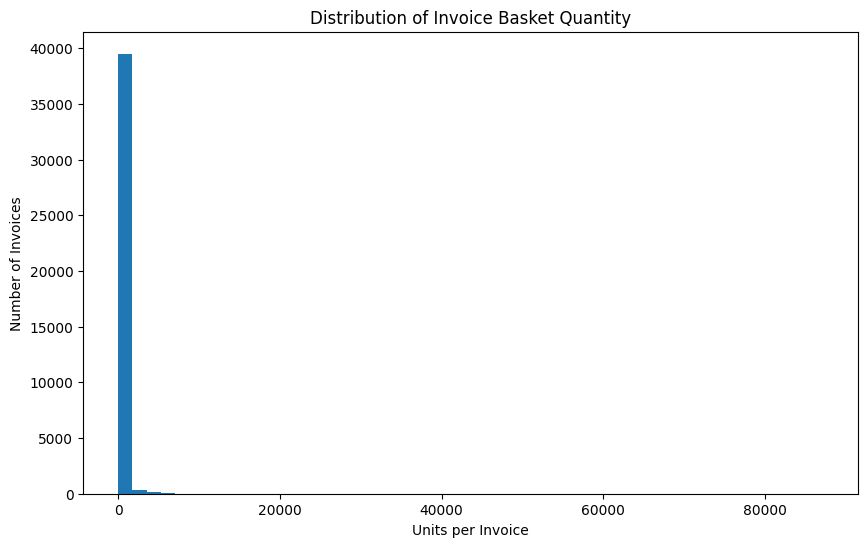

In [126]:
plt.figure(figsize=(10, 6))

plt.hist(invoice_df["Quantity"], bins=50)

plt.title("Distribution of Invoice Basket Quantity")
plt.xlabel("Units per Invoice")
plt.ylabel("Number of Invoices")

plt.show()

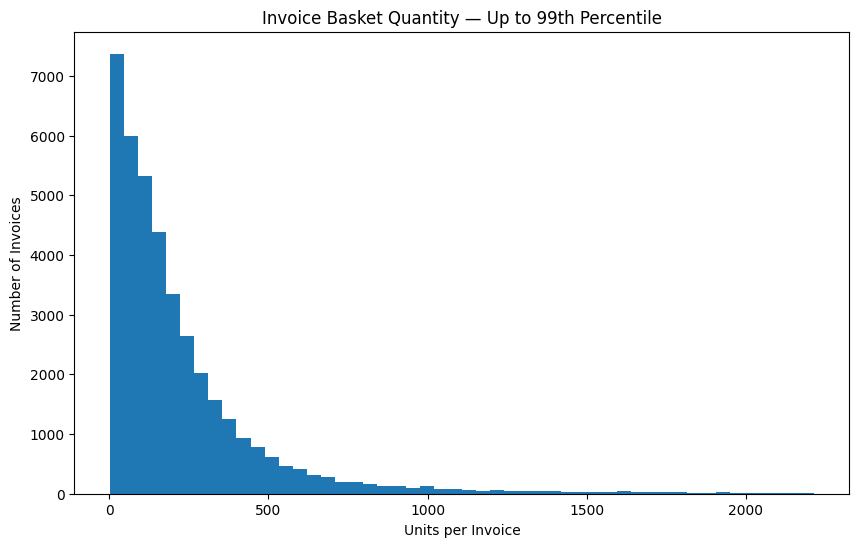

In [127]:
plt.figure(figsize=(10, 6))

plt.hist(
    invoice_df.loc[
        invoice_df["Quantity"] <= invoice_df["Quantity"].quantile(0.99),
        "Quantity"
    ],
    bins=50
)

plt.title("Invoice Basket Quantity — Up to 99th Percentile")
plt.xlabel("Units per Invoice")
plt.ylabel("Number of Invoices")

plt.show()

## Interpretation
Invoice‑level quantities are also right‑skewed. The median invoice has 151 units, but the mean is 284 – again driven by a small number of very large baskets. The 99th percentile is around 2,000 units; the maximum is 87,167.

In [128]:
invoice_df["Revenue"].describe()

count    40,077.00
mean        510.92
std       1,482.33
min           0.19
25%         149.75
50%         302.22
75%         493.40
max     168,469.60
Name: Revenue, dtype: float64

In [129]:
aov = invoice_df["Revenue"]

print("Average Order Value (£):", round(aov.mean(), 2))
print("Median Order Value (£):", round(aov.median(), 2))

Average Order Value (£): 510.92
Median Order Value (£): 302.22


In [130]:
median_aov = invoice_df["Revenue"].median()

print(f"Median Order Value: £{median_aov:,.2f}")

Median Order Value: £302.22


## Interpretation
The average order value is significantly higher than the median, again reflecting the impact of high‑value orders. Most invoices are under £500, but a few exceed £10,000.

In [131]:
product_summary = (
    df.groupby("StockCode")
      .agg(
          Quantity=("Quantity", "sum"),
          Revenue=("Revenue", "sum"),
          Invoices=("Invoice", "nunique"),
          Customers=("Customer ID", "nunique")
      )
      .reset_index()
)

In [132]:
product_summary.head()

,StockCode,Quantity,Revenue,Invoices,Customers
0,10002,8671,"6,942.26",362,164
1,10002R,4,20.57,3,0
2,10080,315,129.29,27,23
3,10109,4,1.68,1,1
4,10120,664,142.74,73,52


In [133]:
top_quantity = (
    product_summary
    .sort_values("Quantity", ascending=False)
    .head(10)
)

top_quantity

,StockCode,Quantity,Revenue,Invoices,Customers
3541,84077,106139,"24,445.61",1019,482
4272,85099B,96757,"180,569.34",3989,978
615,21212,94884,"51,825.15",3118,1115
4300,85123A,94203,"257,724.71",5365,1490
1433,22197,88499,"79,520.20",2322,601
2798,23843,80995,"168,469.60",1,1
3990,84879,80082,"129,324.49",2807,1010
2353,23166,78033,"81,700.92",247,138
114,17003,70369,"14,766.42",456,215
1246,21977,56061,"28,081.73",1993,767


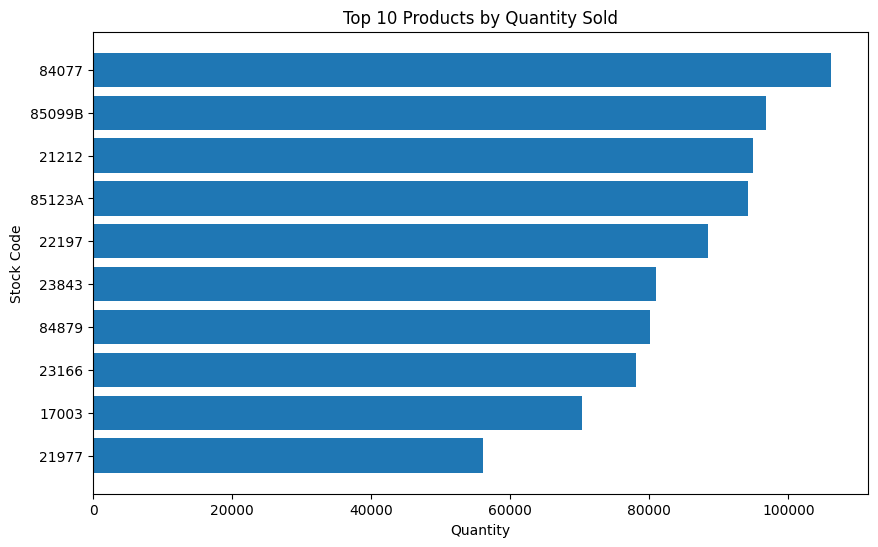

In [134]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_quantity["StockCode"].astype(str),
    top_quantity["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Stock Code")

plt.gca().invert_yaxis()

plt.show()

In [135]:
top_revenue = (
    product_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_revenue

,StockCode,Quantity,Revenue,Invoices,Customers
4901,M,9629,"339,226.24",784,438
1638,22423,26478,"330,590.32",3918,1314
4900,DOT,1415,"309,854.11",1415,1
4300,85123A,94203,"257,724.71",5365,1490
4272,85099B,96757,"180,569.34",3989,978
2798,23843,80995,"168,469.60",1,1
3147,47566,28200,"148,318.28",2674,894
3990,84879,80082,"129,324.49",2807,1010
4903,POST,5363,"125,682.42",1851,405
1326,22086,35084,"117,760.29",2018,896


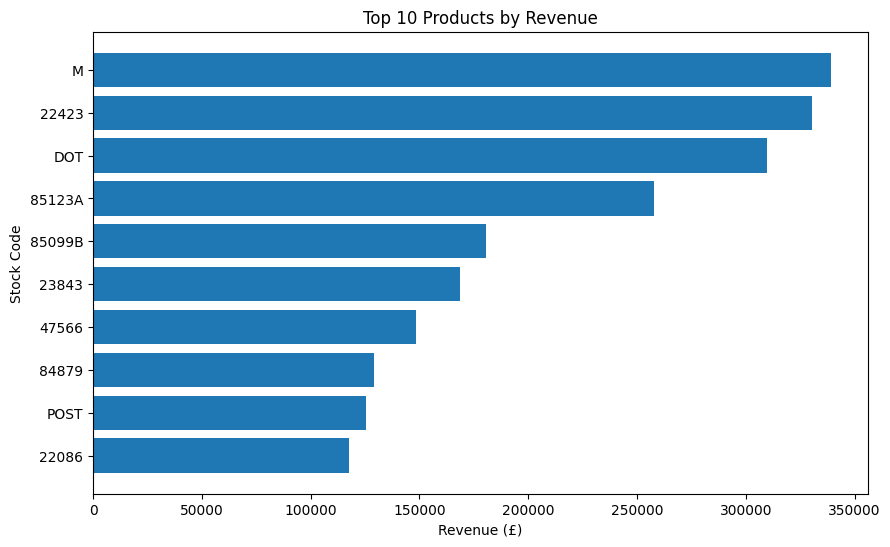

In [136]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue["StockCode"].astype(str),
    top_revenue["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Stock Code")

plt.gca().invert_yaxis()

plt.show()

## Interpretation
There is a notable difference between top‑quantity and top‑revenue products. For example, product M has relatively low quantity (9,629) but generates the highest revenue (£339k), while 84077 sells the most units (106k) but yields modest revenue (£24k). This highlights the importance of analysing both volume and monetary contribution. One product (23843) appears in both lists but was bought by only one customer in a single invoice – an extreme outlier.

In [137]:
product_pareto = (
    product_summary
    .sort_values("Revenue", ascending=False)
    .copy()
)

product_pareto["CumulativeRevenue"] = (
    product_pareto["Revenue"].cumsum()
)

product_pareto["CumulativeRevenuePct"] = (
    product_pareto["CumulativeRevenue"]
    / product_pareto["Revenue"].sum()
    * 100
)

In [138]:
products_for_80 = (
    product_pareto["CumulativeRevenuePct"] <= 80
).sum()

print("Products contributing to first 80% of cumulative revenue:",
      products_for_80)

print("Total products:", len(product_pareto))

Products contributing to first 80% of cumulative revenue: 1008
Total products: 4916


## Pareto (80/20) Analysis
The cumulative revenue curve shows that the top ~20% of products account for approximately 80% of total revenue, confirming a classic Pareto distribution. This concentration will influence product‑related feature engineering and inventory focus.



In [139]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [140]:
invoice_df["InvoiceDate"] = pd.to_datetime(invoice_df["InvoiceDate"])

invoice_df["Year"] = invoice_df["InvoiceDate"].dt.year
invoice_df["Month"] = invoice_df["InvoiceDate"].dt.month
invoice_df["MonthName"] = invoice_df["InvoiceDate"].dt.month_name()
invoice_df["DayOfWeek"] = invoice_df["InvoiceDate"].dt.day_name()
invoice_df["Hour"] = invoice_df["InvoiceDate"].dt.hour

In [141]:
monthly_revenue = (
    invoice_df
    .groupby(invoice_df["InvoiceDate"].dt.to_period("M"))
    ["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["InvoiceDate"] = (
    monthly_revenue["InvoiceDate"].dt.to_timestamp()
)

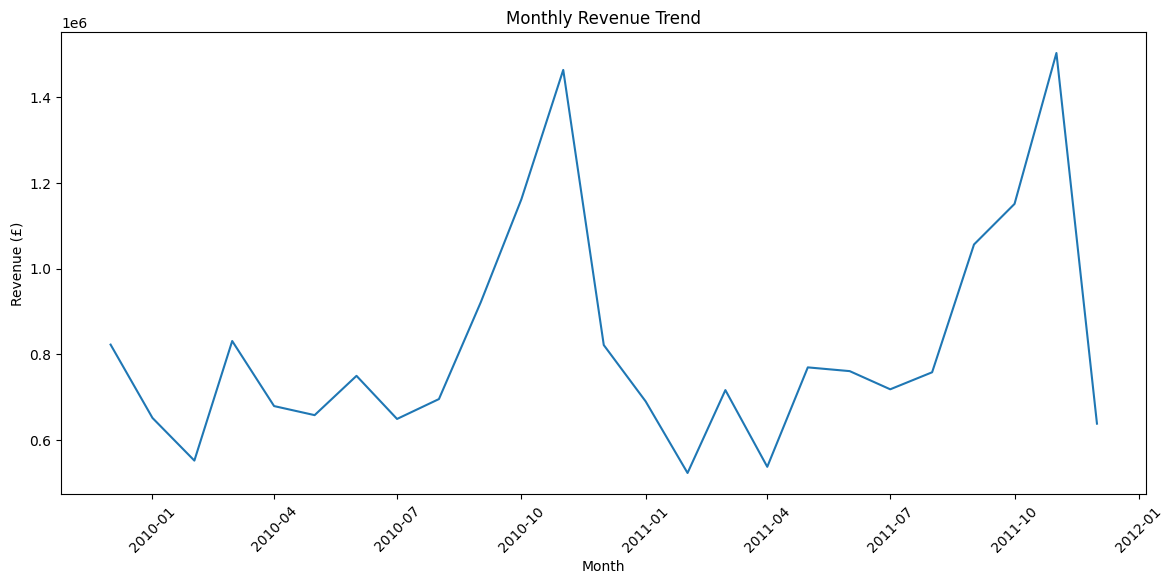

In [142]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["InvoiceDate"],
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.show()

In [143]:
monthly_transactions = (
    invoice_df
    .groupby(invoice_df["InvoiceDate"].dt.to_period("M"))
    ["Invoice"]
    .nunique()
    .reset_index(name="Transactions")
)

monthly_transactions["InvoiceDate"] = (
    monthly_transactions["InvoiceDate"].dt.to_timestamp()
)

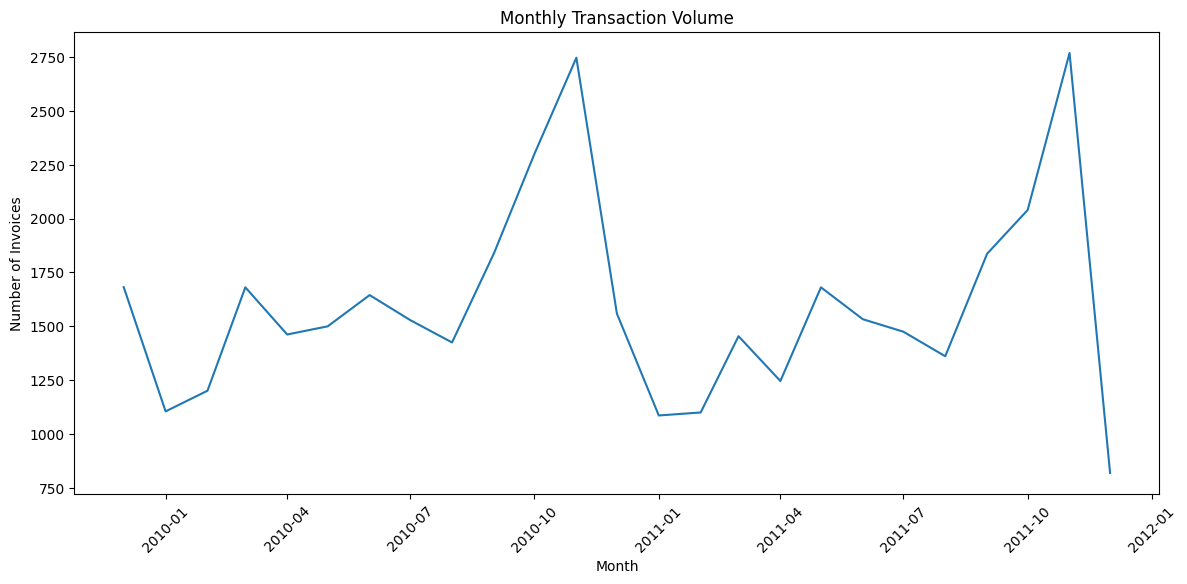

In [144]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_transactions["InvoiceDate"],
    monthly_transactions["Transactions"]
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Invoices")

plt.xticks(rotation=45)

plt.show()

In [145]:
monthly_customers = (
    invoice_df
    .groupby(invoice_df["InvoiceDate"].dt.to_period("M"))
    ["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
)

monthly_customers["InvoiceDate"] = (
    monthly_customers["InvoiceDate"].dt.to_timestamp()
)

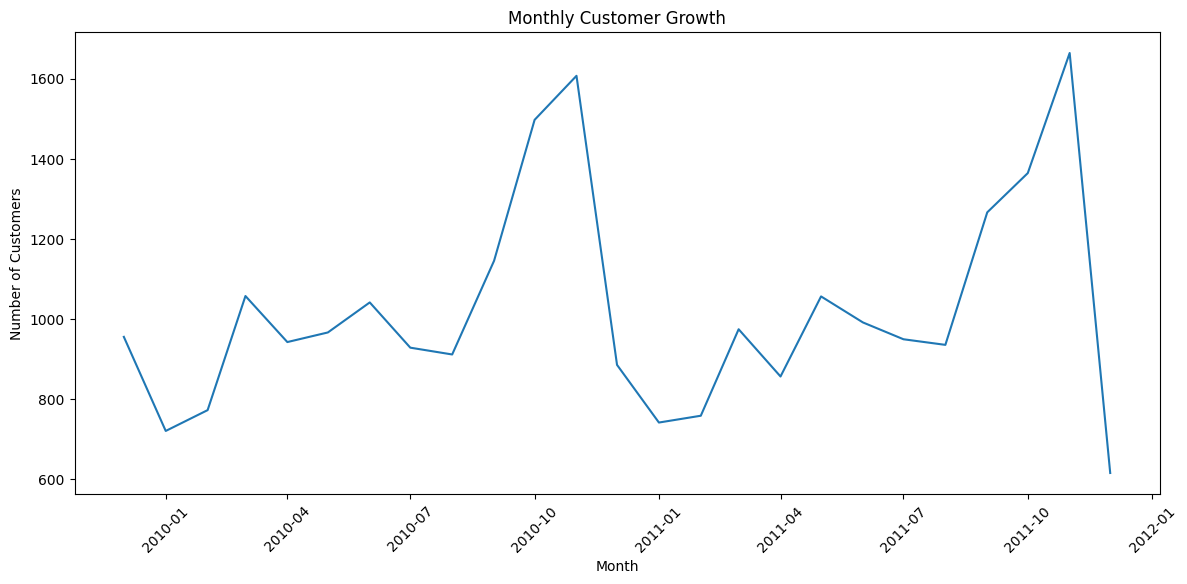

In [146]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_customers["InvoiceDate"],
    monthly_customers["Customers"]
)

plt.title("Monthly Customer Growth")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [147]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = (
    invoice_df
    .groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(day_order)
)

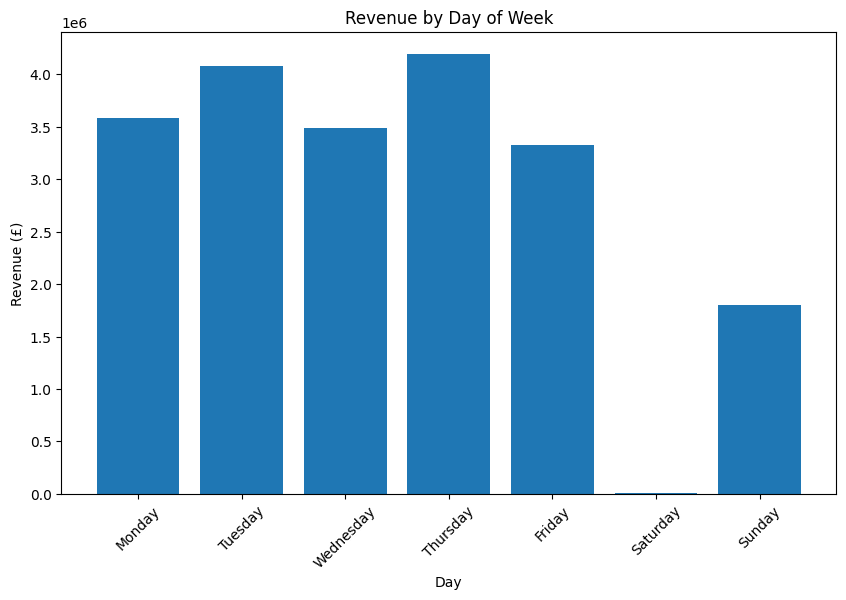

In [148]:
plt.figure(figsize=(10, 6))

plt.bar(
    weekday_revenue.index,
    weekday_revenue.values
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.show()

In [149]:
hourly_transactions = (
    invoice_df
    .groupby("Hour")["Invoice"]
    .nunique()
)

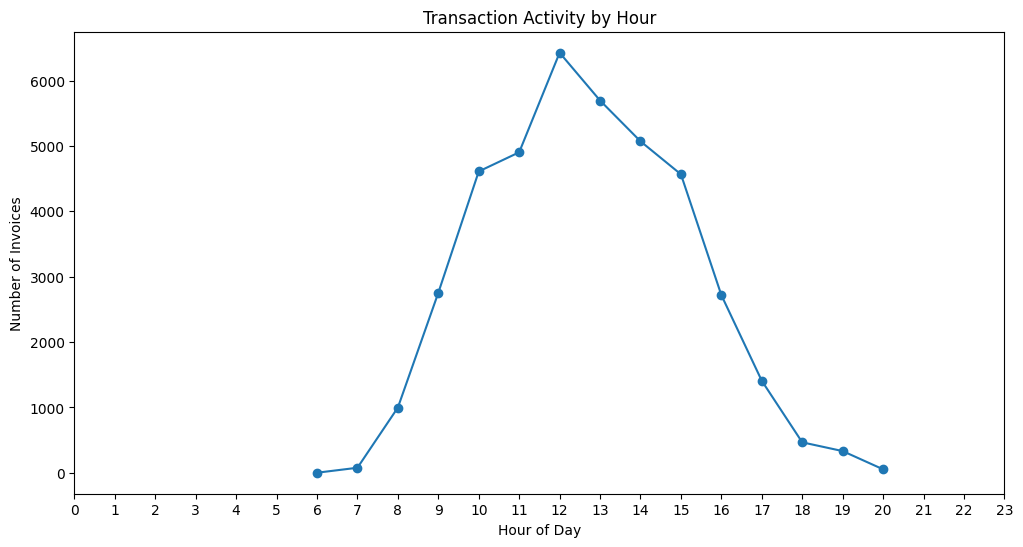

In [150]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_transactions.index,
    hourly_transactions.values,
    marker="o"
)

plt.title("Transaction Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Invoices")

plt.xticks(range(0, 24))

plt.show()

In [151]:
country_summary = (
    df.groupby("Country")
      .agg(
          Revenue=("Revenue", "sum"),
          Quantity=("Quantity", "sum"),
          Customers=("Customer ID", "nunique"),
          Invoices=("Invoice", "nunique")
      )
      .reset_index()
)

In [152]:
top_countries = (
    country_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_countries

,Country,Revenue,Quantity,Customers,Invoices
40,United Kingdom,"17,410,196.12",9187753,5350,36535
11,EIRE,"658,767.31",336329,5,626
26,Netherlands,"554,038.09",383879,22,228
15,Germany,"425,019.71",225154,107,789
14,France,"350,456.09",271901,95,622
0,Australia,"169,283.46",103759,15,95
34,Spain,"108,332.49",50307,41,154
36,Switzerland,"100,685.59",52762,22,93
35,Sweden,"91,869.82",88633,19,105
10,Denmark,"68,580.69",237471,12,43


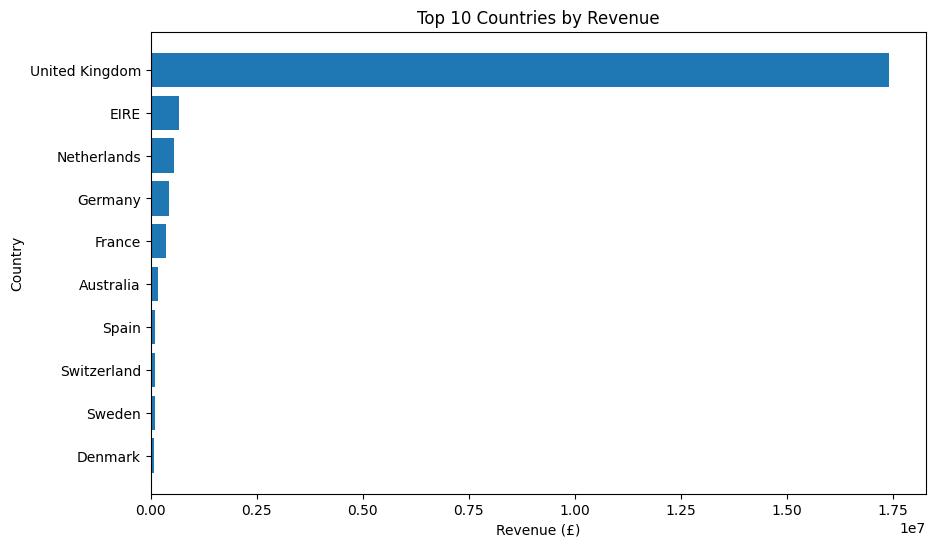

In [153]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

In [154]:
# ============================================================
# CREATE CUSTOMER-LEVEL ANALYTICAL TABLE
# ============================================================

customer_summary = (
    invoice_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Invoices=("Invoice", "nunique"),
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        UniqueProducts=("UniqueProducts", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        Countries=("Country", "nunique")
    )
    .reset_index()
)

print(
    "Identifiable customers:",
    customer_summary["CustomerID"].nunique()
)

customer_summary.head()

Identifiable customers: 5878


,CustomerID,Invoices,Revenue,Quantity,UniqueProducts,FirstPurchase,LastPurchase,Countries
0,"12,346.00",12,"77,556.46",74285,34,2009-12-14 08:34:00,2011-01-18 10:01:00,1
1,"12,347.00",8,"4,921.53",2967,222,2010-10-31 14:20:00,2011-12-07 15:52:00,1
2,"12,348.00",5,"2,019.40",2714,47,2010-09-27 14:59:00,2011-09-25 13:13:00,1
3,"12,349.00",4,"4,428.69",1624,175,2010-04-29 13:20:00,2011-11-21 09:51:00,1
4,"12,350.00",1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,1


In [155]:
# ============================================================
# CUSTOMER AVERAGE ORDER VALUE
# ============================================================

customer_summary["AverageOrderValue"] = (
    customer_summary["Revenue"]
    / customer_summary["Invoices"]
)

customer_summary.head()

,CustomerID,Invoices,Revenue,Quantity,UniqueProducts,FirstPurchase,LastPurchase,Countries,AverageOrderValue
0,"12,346.00",12,"77,556.46",74285,34,2009-12-14 08:34:00,2011-01-18 10:01:00,1,"6,463.04"
1,"12,347.00",8,"4,921.53",2967,222,2010-10-31 14:20:00,2011-12-07 15:52:00,1,615.19
2,"12,348.00",5,"2,019.40",2714,47,2010-09-27 14:59:00,2011-09-25 13:13:00,1,403.88
3,"12,349.00",4,"4,428.69",1624,175,2010-04-29 13:20:00,2011-11-21 09:51:00,1,"1,107.17"
4,"12,350.00",1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40


In [156]:
customer_summary["Invoices"].describe()

count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: Invoices, dtype: float64

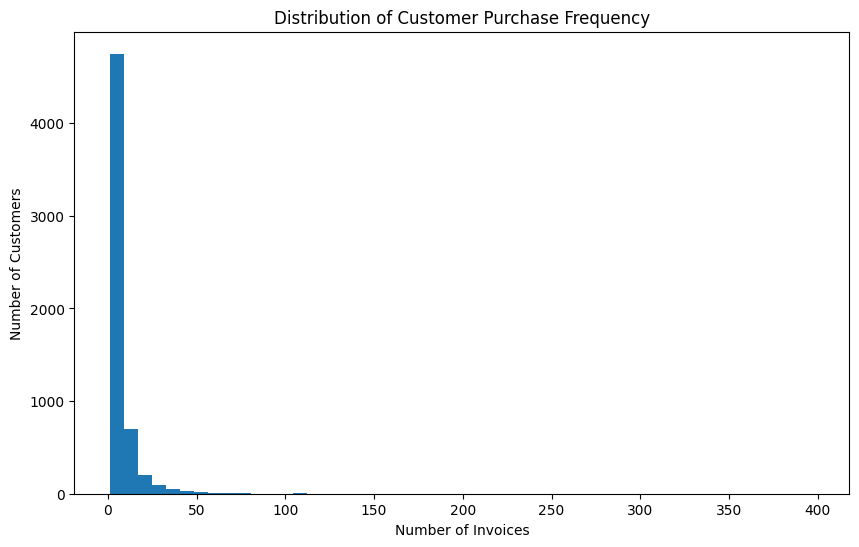

In [157]:
plt.figure(figsize=(10, 6))

plt.hist(customer_summary["Invoices"], bins=50)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Invoices")
plt.ylabel("Number of Customers")

plt.show()

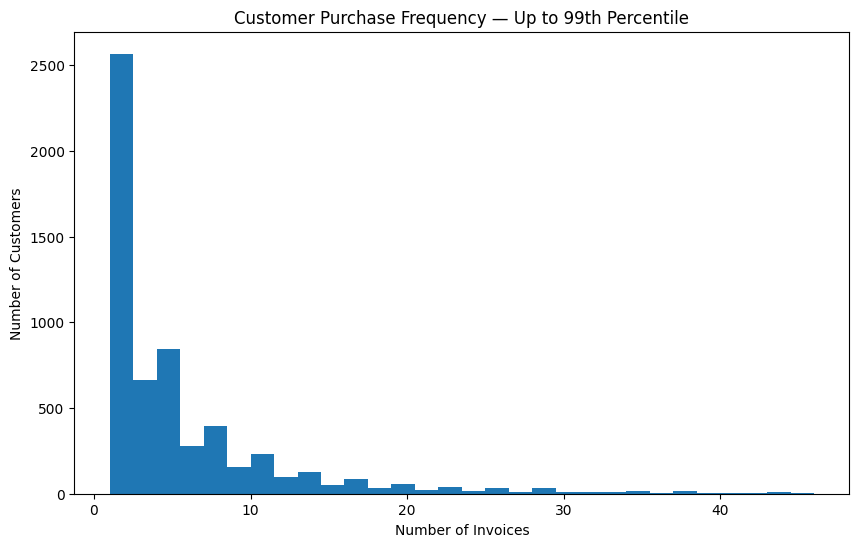

In [158]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary.loc[
        customer_summary["Invoices"] <=
        customer_summary["Invoices"].quantile(0.99),
        "Invoices"
    ],
    bins=30
)

plt.title("Customer Purchase Frequency — Up to 99th Percentile")
plt.xlabel("Number of Invoices")
plt.ylabel("Number of Customers")

plt.show()

In [159]:
customer_summary["Revenue"].describe()

count     5,878.00
mean      2,955.90
std      14,440.85
min           2.95
25%         342.28
50%         867.74
75%       2,248.31
max     580,987.04
Name: Revenue, dtype: float64

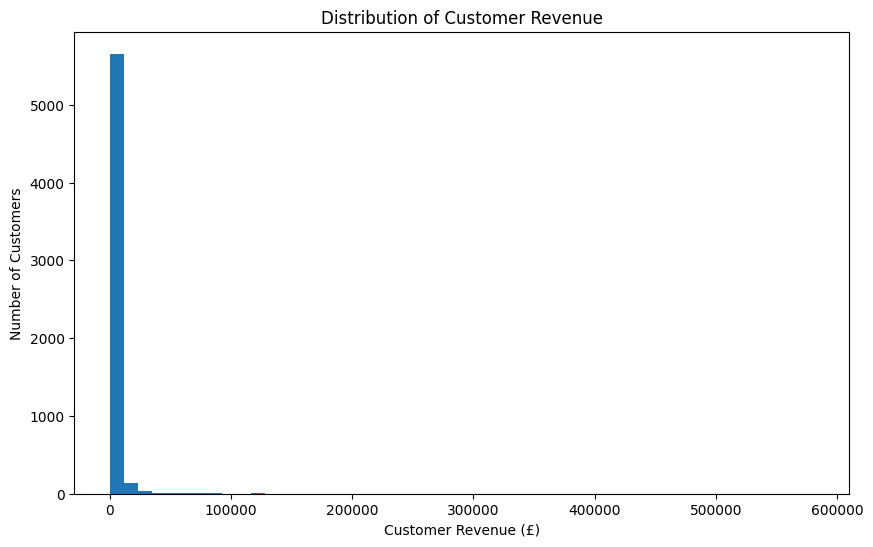

In [160]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary["Revenue"],
    bins=50
)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue (£)")
plt.ylabel("Number of Customers")

plt.show()

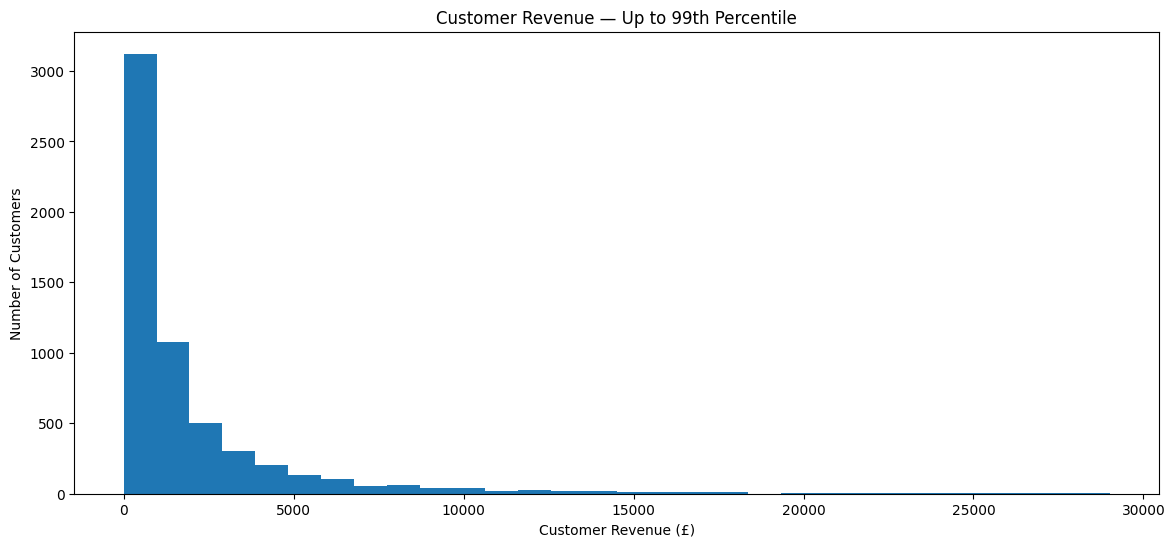

In [161]:
plt.figure(figsize=(14, 6))

plt.hist(
    customer_summary.loc[
        customer_summary["Revenue"] <=
        customer_summary["Revenue"].quantile(0.99),
        "Revenue"
    ],
    bins=30
)

plt.title("Customer Revenue — Up to 99th Percentile")
plt.xlabel("Customer Revenue (£)")
plt.ylabel("Number of Customers")

plt.show()

In [162]:
one_time = (customer_summary["Invoices"] == 1).sum()

repeat = (customer_summary["Invoices"] > 1).sum()

total_customers = len(customer_summary)

print("One-time customers:", one_time)
print("Repeat customers:", repeat)
print("Total identifiable customers:", total_customers)

print(
    f"One-time percentage: {one_time / total_customers * 100:.2f}%"
)

print(
    f"Repeat percentage: {repeat / total_customers * 100:.2f}%"
)

One-time customers: 1623
Repeat customers: 4255
Total identifiable customers: 5878
One-time percentage: 27.61%
Repeat percentage: 72.39%


In [163]:
customer_pareto = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .copy()
)

customer_pareto["CumulativeRevenue"] = (
    customer_pareto["Revenue"].cumsum()
)

customer_pareto["CumulativeRevenuePct"] = (
    customer_pareto["CumulativeRevenue"]
    / customer_pareto["Revenue"].sum()
    * 100
)

In [164]:
customer_pareto.head(20)

,CustomerID,Invoices,Revenue,Quantity,UniqueProducts,FirstPurchase,LastPurchase,Countries,AverageOrderValue,CumulativeRevenue,CumulativeRevenuePct
5692,"18,102.00",145,"580,987.04",181645,1040,2009-12-01 09:24:00,2011-12-09 11:50:00,1,"4,006.81","580,987.04",3.34
2277,"14,646.00",151,"528,602.52",367193,3846,2009-12-02 16:52:00,2011-12-08 12:12:00,1,"3,500.68","1,109,589.56",6.39
1789,"14,156.00",156,"313,437.62",164325,4034,2009-12-01 12:30:00,2011-11-30 10:54:00,1,"2,009.22","1,423,027.18",8.19
2538,"14,911.00",398,"291,420.81",147972,11077,2009-12-01 11:41:00,2011-12-08 15:54:00,1,732.21,"1,714,447.99",9.87
5050,"17,450.00",51,"244,784.25",83914,420,2010-09-27 16:59:00,2011-12-01 13:29:00,1,"4,799.69","1,959,232.24",11.28
1331,"13,694.00",143,"195,640.69",188201,1519,2009-12-04 15:26:00,2011-12-06 09:32:00,1,"1,368.12","2,154,872.93",12.40
5109,"17,511.00",60,"172,132.87",117174,1868,2009-12-02 10:52:00,2011-12-07 10:12:00,1,"2,868.88","2,327,005.80",13.39
4061,"16,446.00",2,"168,472.50",80997,3,2011-05-18 09:52:00,2011-12-09 09:15:00,1,"84,236.25","2,495,478.30",14.36
4295,"16,684.00",55,"147,142.77",104810,718,2009-12-07 12:56:00,2011-12-05 14:06:00,1,"2,675.32","2,642,621.07",15.21
68,"12,415.00",28,"144,458.37",91447,926,2010-06-30 08:30:00,2011-11-15 14:22:00,1,"5,159.23","2,787,079.44",16.04


In [165]:
# ============================================================
# CUSTOMER PURCHASE INTERVALS
# ============================================================

customer_invoices = (
    invoice_df
    .dropna(subset=["CustomerID"])
    [
        [
            "CustomerID",
            "Invoice",
            "InvoiceDate"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["CustomerID", "InvoiceDate", "Invoice"]
    )
    .reset_index(drop=True)
)

customer_invoices["PurchaseIntervalDays"] = (
    customer_invoices
    .groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    / (24 * 60 * 60)
)

purchase_intervals = (
    customer_invoices["PurchaseIntervalDays"]
    .dropna()
)

print(
    "Number of purchase intervals:",
    len(purchase_intervals)
)

purchase_intervals.describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

Number of purchase intervals: 31091


count   31,091.00
mean        51.69
std         75.79
min          0.00
50%         24.74
75%         61.81
90%        134.88
95%        206.43
99%        368.74
max        714.15
Name: PurchaseIntervalDays, dtype: float64

In [166]:
# ============================================================
# SAME-DAY PURCHASE INTERVAL CHECK
# ============================================================

zero_day = (
    purchase_intervals == 0
).sum()

print(
    "Same-day purchase intervals:",
    zero_day
)

print(
    "Percentage:",
    round(
        zero_day / len(purchase_intervals) * 100,
        2
    ),
    "%"
)

Same-day purchase intervals: 181
Percentage: 0.58 %


In [167]:
# ============================================================
# CUSTOMER RECENCY AND 60-DAY AT-RISK INDICATOR
# ============================================================

observation_date = invoice_df["InvoiceDate"].max()

customer_summary["RecencyDays"] = (
    observation_date
    - customer_summary["LastPurchase"]
).dt.total_seconds() / (24 * 60 * 60)

customer_summary["AtRisk60"] = (
    customer_summary["RecencyDays"] >= 60
)

print("Observation date:", observation_date)

print(
    "Customers inactive for 60+ days:",
    customer_summary["AtRisk60"].sum()
)

print(
    "Percentage:",
    round(
        customer_summary["AtRisk60"].mean() * 100,
        2
    ),
    "%"
)

Observation date: 2011-12-09 12:50:00
Customers inactive for 60+ days: 3482
Percentage: 59.24 %


In [168]:
# ============================================================
# INACTIVITY THRESHOLD COMPARISON
# ============================================================

thresholds = [30, 60, 90, 120, 180]

threshold_results = []

for threshold in thresholds:

    inactive = (
        customer_summary["RecencyDays"] >= threshold
    ).sum()

    percentage = (
        inactive /
        len(customer_summary)
        * 100
    )

    threshold_results.append({
        "ThresholdDays": threshold,
        "InactiveCustomers": inactive,
        "Percentage": round(percentage, 2)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,ThresholdDays,InactiveCustomers,Percentage
0,30,4230,71.96
1,60,3482,59.24
2,90,2989,50.85
3,120,2757,46.90
4,180,2400,40.83


In [169]:
customer_invoices["PurchaseIntervalDays"] = (
    customer_invoices
    .groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    / (24 * 60 * 60)
)

In [170]:
purchase_intervals = (
    customer_invoices["PurchaseIntervalDays"]
    .dropna()
)

purchase_intervals.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count   31,091.00
mean        51.69
std         75.79
min          0.00
50%         24.74
75%         61.81
90%        134.88
95%        206.43
99%        368.74
max        714.15
Name: PurchaseIntervalDays, dtype: float64

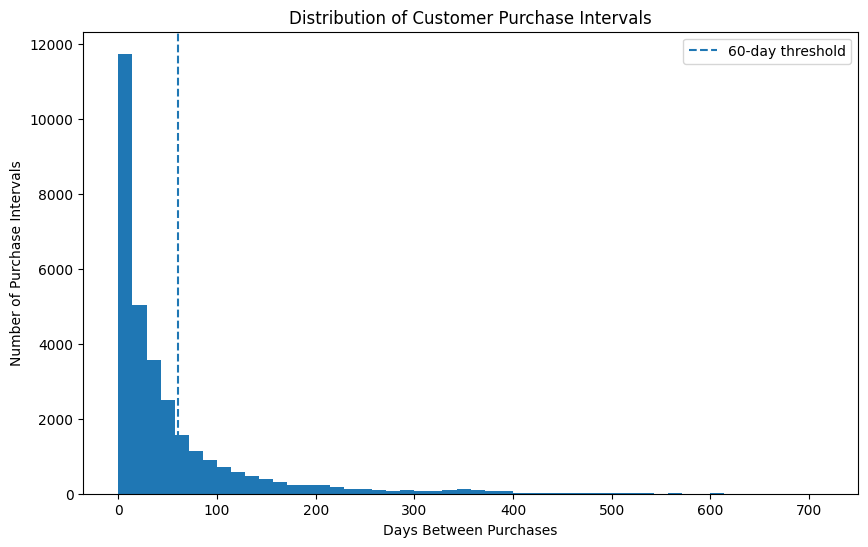

In [171]:
plt.figure(figsize=(10, 6))

plt.hist(
    purchase_intervals,
    bins=50
)

plt.axvline(
    60,
    linestyle="--",
    label="60-day threshold"
)

plt.title("Distribution of Customer Purchase Intervals")
plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchase Intervals")

plt.legend()

plt.show()

## Interpretation
The median time between purchases is about 25 days, but the mean is nearly 52 days, again due to extreme gaps. The 75th percentile (~62 days) suggests that a 60‑day threshold is a reasonable operational definition for “at‑risk” customers, as it covers the majority of intervals. However, many customers have intervals exceeding 60 days, indicating natural churn or seasonal buying.

In [172]:
zero_day = (purchase_intervals == 0).sum()

print("Same-day purchase intervals:", zero_day)

print(
    f"Percentage: {zero_day / len(purchase_intervals) * 100:.2f}%"
)

Same-day purchase intervals: 181
Percentage: 0.58%


In [173]:
observation_date = invoice_df["InvoiceDate"].max()

observation_date

Timestamp('2011-12-09 12:50:00')

In [174]:
customer_summary["RecencyDays"] = (
    observation_date - customer_summary["LastPurchase"]
).dt.total_seconds() / (24 * 60 * 60)

In [175]:
customer_summary["AtRisk60"] = (
    customer_summary["RecencyDays"] >= 60
)

In [176]:
at_risk_count = customer_summary["AtRisk60"].sum()
total_customers = len(customer_summary)

print("Customers inactive for at least 60 days:", at_risk_count)

print(
    f"Percentage: {at_risk_count / total_customers * 100:.2f}%"
)

Customers inactive for at least 60 days: 3482
Percentage: 59.24%


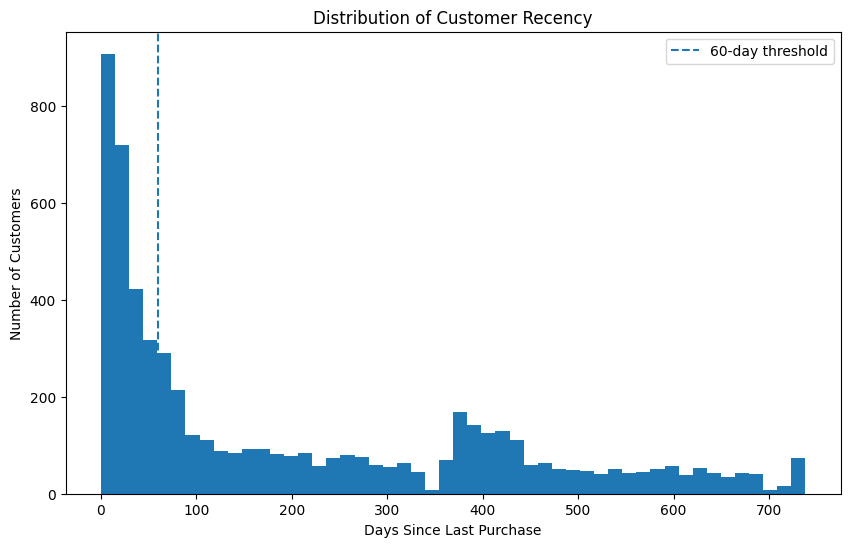

In [177]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_summary["RecencyDays"],
    bins=50
)

plt.axvline(
    60,
    linestyle="--",
    label="60-day threshold"
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.legend()

plt.show()

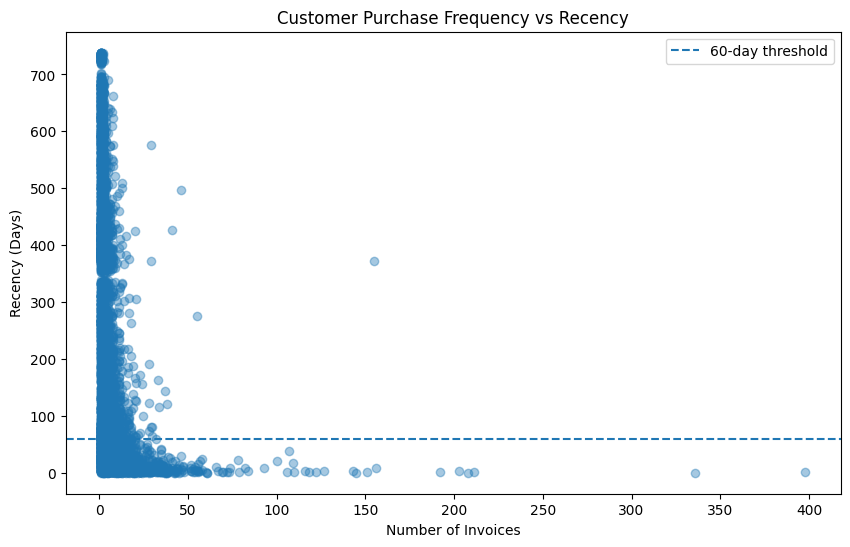

In [178]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Invoices"],
    customer_summary["RecencyDays"],
    alpha=0.4
)

plt.axhline(
    60,
    linestyle="--",
    label="60-day threshold"
)

plt.title("Customer Purchase Frequency vs Recency")
plt.xlabel("Number of Invoices")
plt.ylabel("Recency (Days)")

plt.legend()

plt.show()

## Interpretation
There is a negative relationship between purchase frequency and recency – loyal, frequent buyers are more likely to have purchased recently. This supports the use of frequency as a key retention signal.



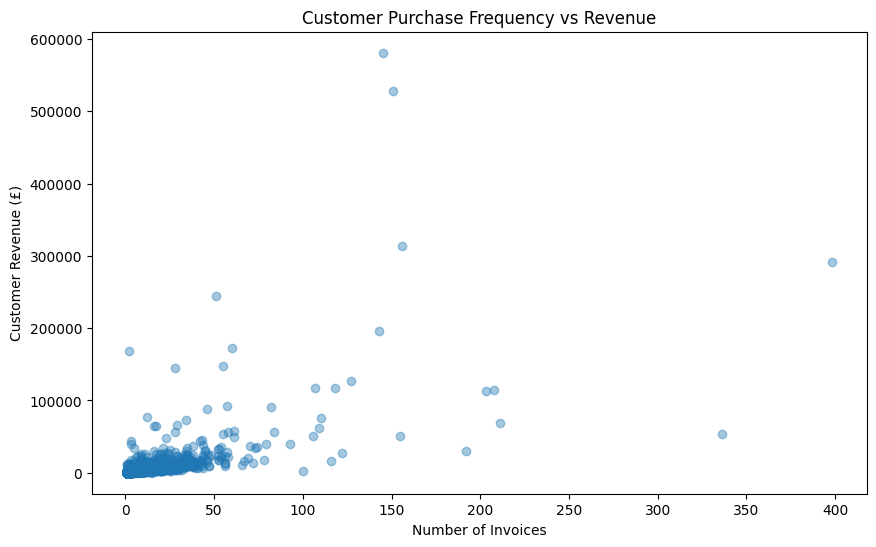

In [179]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Invoices"],
    customer_summary["Revenue"],
    alpha=0.4
)

plt.title("Customer Purchase Frequency vs Revenue")
plt.xlabel("Number of Invoices")
plt.ylabel("Customer Revenue (£)")

plt.show()

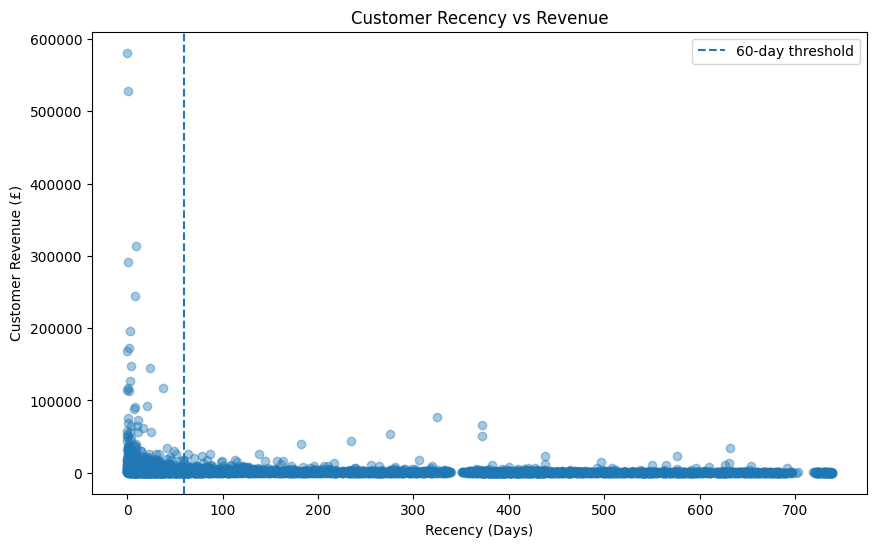

In [180]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["RecencyDays"],
    customer_summary["Revenue"],
    alpha=0.4
)

plt.axvline(
    60,
    linestyle="--",
    label="60-day threshold"
)

plt.title("Customer Recency vs Revenue")
plt.xlabel("Recency (Days)")
plt.ylabel("Customer Revenue (£)")

plt.legend()

plt.show()

In [181]:
correlation_data = customer_summary[
    [
        "RecencyDays",
        "Invoices",
        "Revenue",
        "Quantity",
        "Countries"
    ]
]

In [182]:
correlation_data.corr()

,RecencyDays,Invoices,Revenue,Quantity,Countries
RecencyDays,1.00,-0.26,-0.13,-0.11,-0.02
Invoices,-0.26,1.00,0.63,0.57,0.01
Revenue,-0.13,0.63,1.00,0.87,0.00
Quantity,-0.11,0.57,0.87,1.00,0.00
Countries,-0.02,0.01,0.00,0.00,1.00


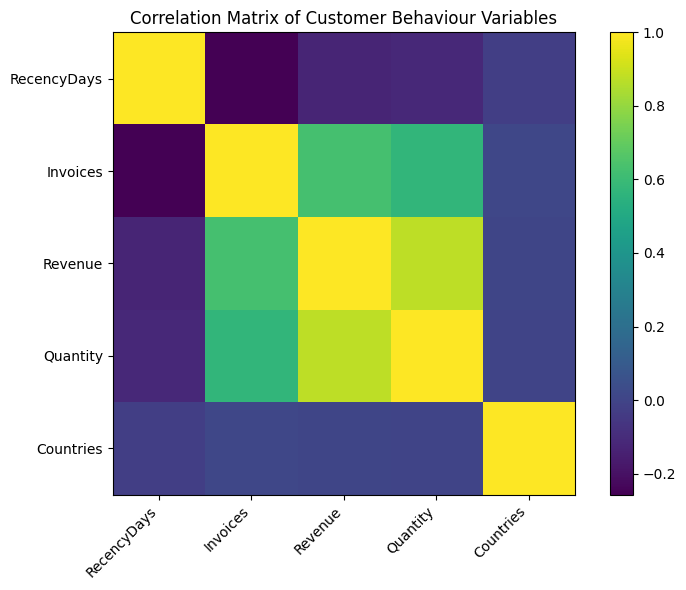

In [183]:
corr = correlation_data.corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix of Customer Behaviour Variables")

plt.tight_layout()

plt.show()

Interpretation

Revenue and Quantity are strongly positively correlated (r = 0.87) – higher spending goes with higher volume.

Invoices (frequency) is moderately correlated with both Revenue (0.63) and Quantity (0.57) – frequent buyers are more valuable.

Recency has weak negative correlations with all other variables, suggesting that recent activity is only slightly associated with higher spending or frequency.

Countries shows almost no correlation – most customers are from a single country.

These relationships confirm that customer value is primarily driven by purchase frequency and volume, not just recency.

In [184]:
# ============================================================
# OFFICIAL EDA KPI SUMMARY
# ============================================================

eda_summary = pd.DataFrame({
    "Metric": [
        "Total transaction lines",
        "Unique invoices",
        "Identifiable customers",
        "Unique products",
        "Countries",
        "Total quantity",
        "Total revenue",
        "Average order value",
        "Median order value",
        "One-time customers",
        "Repeat customers",
        "Mean purchase interval",
        "Median purchase interval",
        "75th percentile purchase interval",
        "60-day at-risk customers"
    ],

    "Value": [
        len(df),
        df["Invoice"].nunique(),
        customer_summary["CustomerID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        df["Quantity"].sum(),
        df["Revenue"].sum(),
        invoice_df["Revenue"].mean(),
        invoice_df["Revenue"].median(),
        (customer_summary["Invoices"] == 1).sum(),
        (customer_summary["Invoices"] > 1).sum(),
        purchase_intervals.mean(),
        purchase_intervals.median(),
        purchase_intervals.quantile(0.75),
        customer_summary["AtRisk60"].sum()
    ]
})

eda_summary

,Metric,Value
0,Total transaction lines,"1,007,913.00"
1,Unique invoices,"40,077.00"
2,Identifiable customers,"5,878.00"
3,Unique products,"4,916.00"
4,Countries,43.00
5,Total quantity,"11,205,148.00"
6,Total revenue,"20,476,260.45"
7,Average order value,510.92
8,Median order value,302.22
9,One-time customers,"1,623.00"


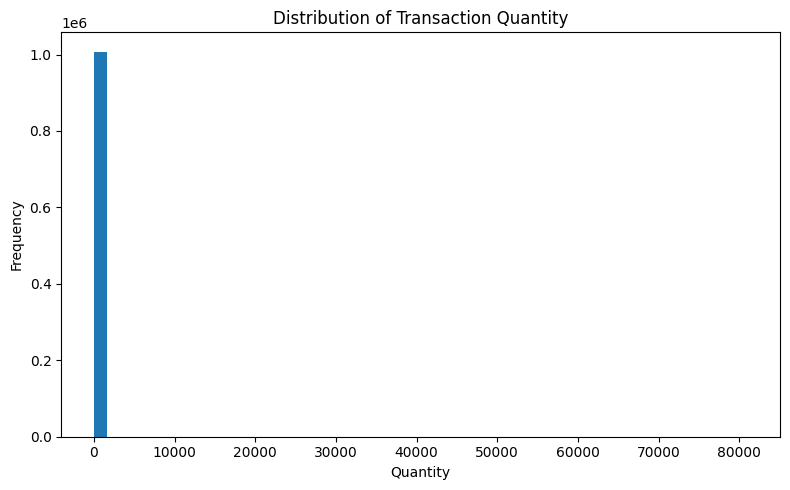

In [185]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Quantity"],
    bins=50
)

plt.title("Distribution of Transaction Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

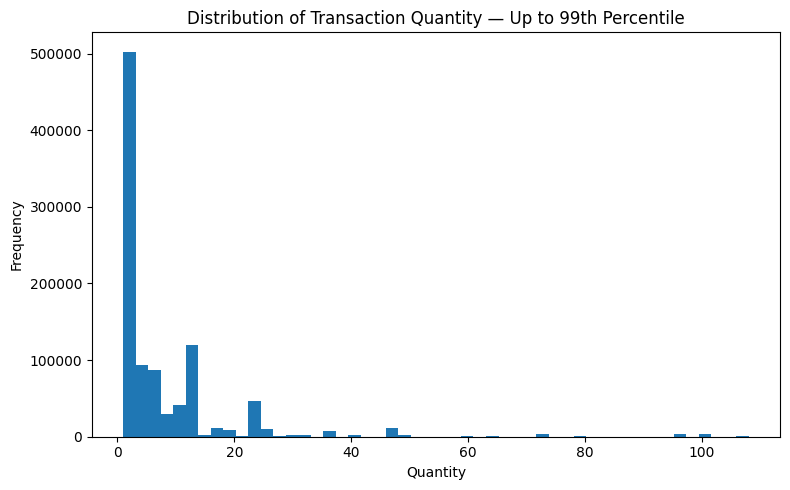

In [186]:
quantity_99 = df["Quantity"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["Quantity"] <= quantity_99, "Quantity"],
    bins=50
)

plt.title("Distribution of Transaction Quantity — Up to 99th Percentile")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

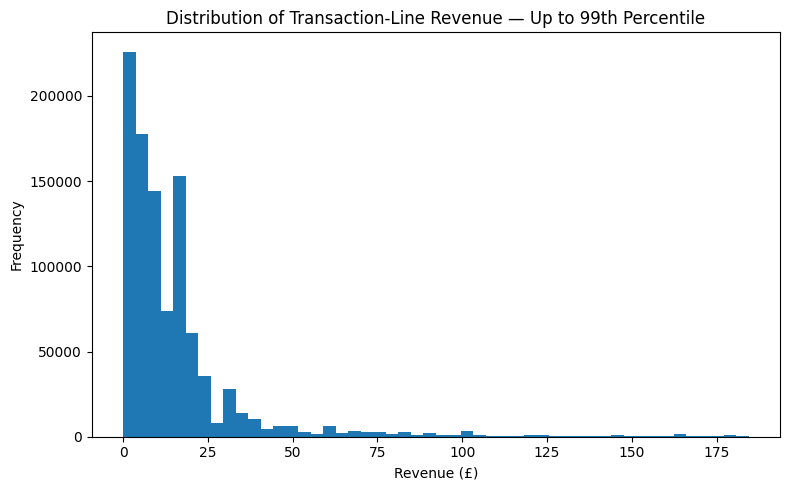

In [187]:
plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["Revenue"] <= df["Revenue"].quantile(0.99), "Revenue"],
    bins=50
)

plt.title("Distribution of Transaction-Line Revenue — Up to 99th Percentile")
plt.xlabel("Revenue (£)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [188]:
print("Revenue median:", df["Revenue"].median())
print("Revenue mean:", df["Revenue"].mean())
print("Revenue 99th percentile:", df["Revenue"].quantile(0.99))
print("Revenue maximum:", df["Revenue"].max())

Revenue median: 10.08
Revenue mean: 20.31550386590906
Revenue 99th percentile: 184.58800000000045
Revenue maximum: 168469.6


In [189]:
invoice_df = pd.read_csv(
    "../data/processed/invoice_summary.csv"
)

invoice_df["InvoiceDate"] = pd.to_datetime(
    invoice_df["InvoiceDate"]
)

invoice_df.head()

,Invoice,Customer ID,InvoiceDate,Country,Quantity,Revenue,UniqueProducts,LineItems
0,489434,"13,085.00",2009-12-01 07:45:00,United Kingdom,166,505.30,8,8
1,489435,"13,085.00",2009-12-01 07:46:00,United Kingdom,60,145.80,4,4
2,489436,"13,078.00",2009-12-01 09:06:00,United Kingdom,193,630.33,19,19
3,489437,"15,362.00",2009-12-01 09:08:00,United Kingdom,145,310.75,23,23
4,489438,"18,102.00",2009-12-01 09:24:00,United Kingdom,826,"2,286.24",17,17


In [190]:
invoice_df[
    ["Quantity", "Revenue", "UniqueProducts", "LineItems"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,"37,033.00",283.91,"1,231.29",1.00,72.00,151.00,287.00,"87,167.00"
Revenue,"37,033.00",469.17,"1,358.55",0.38,157.47,302.80,476.80,"168,469.60"
UniqueProducts,"37,033.00",20.76,22.35,1.00,6.00,15.00,27.00,541.00
LineItems,"37,033.00",21.05,22.92,1.00,6.00,15.00,27.00,542.00


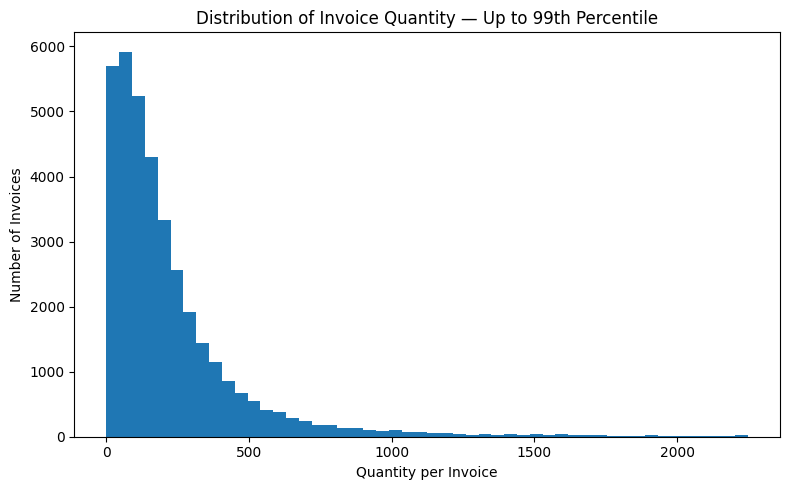

In [191]:
plt.figure(figsize=(8, 5))

plt.hist(
    invoice_df.loc[
        invoice_df["Quantity"] <= invoice_df["Quantity"].quantile(0.99),
        "Quantity"
    ],
    bins=50
)

plt.title("Distribution of Invoice Quantity — Up to 99th Percentile")
plt.xlabel("Quantity per Invoice")
plt.ylabel("Number of Invoices")

plt.tight_layout()
plt.show()

In [192]:
invoice_df["Quantity"].describe()

count   37,033.00
mean       283.91
std      1,231.29
min          1.00
25%         72.00
50%        151.00
75%        287.00
max     87,167.00
Name: Quantity, dtype: float64

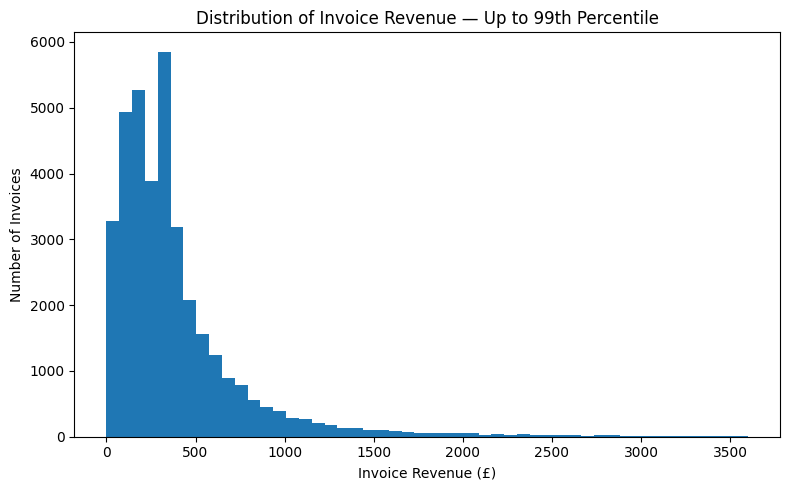

In [193]:
plt.figure(figsize=(8, 5))

plt.hist(
    invoice_df.loc[
        invoice_df["Revenue"] <= invoice_df["Revenue"].quantile(0.99),
        "Revenue"
    ],
    bins=50
)

plt.title("Distribution of Invoice Revenue — Up to 99th Percentile")
plt.xlabel("Invoice Revenue (£)")
plt.ylabel("Number of Invoices")

plt.tight_layout()
plt.show()

In [194]:
invoice_df["Revenue"].describe()

count    37,033.00
mean        469.17
std       1,358.55
min           0.38
25%         157.47
50%         302.80
75%         476.80
max     168,469.60
Name: Revenue, dtype: float64

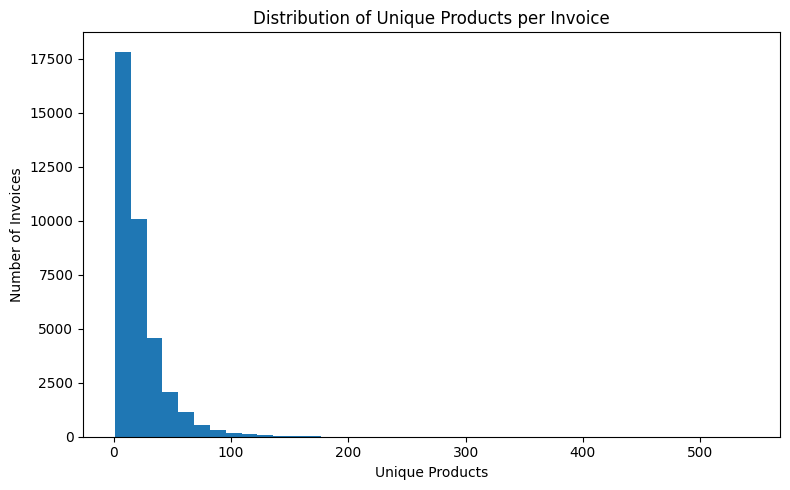

In [195]:
plt.figure(figsize=(8, 5))

plt.hist(
    invoice_df["UniqueProducts"],
    bins=40
)

plt.title("Distribution of Unique Products per Invoice")
plt.xlabel("Unique Products")
plt.ylabel("Number of Invoices")

plt.tight_layout()
plt.show()

In [196]:
invoice_df["UniqueProducts"].describe()

count   37,033.00
mean        20.76
std         22.35
min          1.00
25%          6.00
50%         15.00
75%         27.00
max        541.00
Name: UniqueProducts, dtype: float64

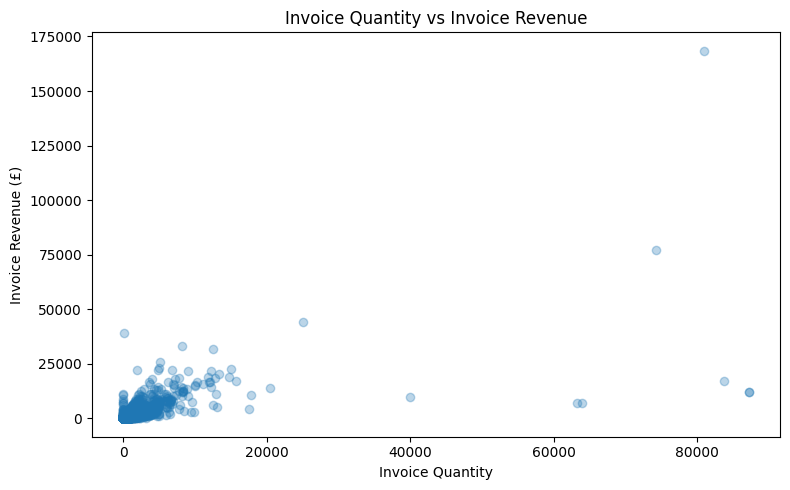

In [197]:
plt.figure(figsize=(8, 5))

plt.scatter(
    invoice_df["Quantity"],
    invoice_df["Revenue"],
    alpha=0.3
)

plt.title("Invoice Quantity vs Invoice Revenue")
plt.xlabel("Invoice Quantity")
plt.ylabel("Invoice Revenue (£)")

plt.tight_layout()
plt.show()

In [198]:
invoice_df[["Quantity", "Revenue"]].corr()

,Quantity,Revenue
Quantity,1.00,0.65
Revenue,0.65,1.00


##  SECTION 2 — DISTRIBUTIONS & OUTLIERS

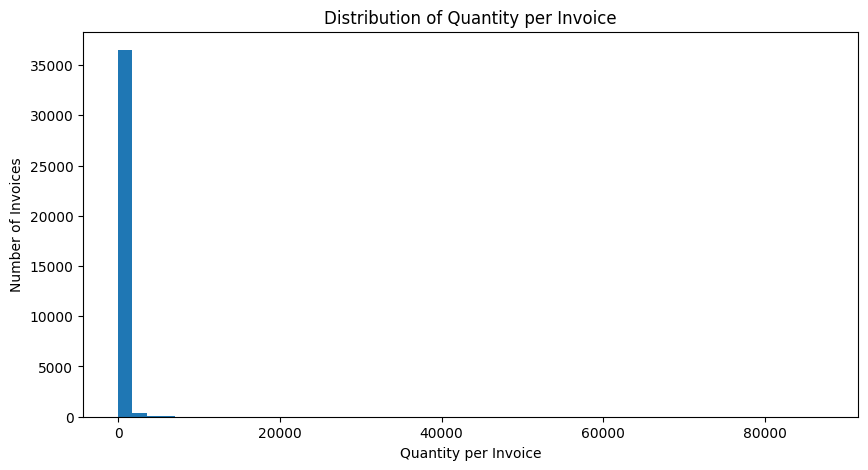

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(invoice_df["Quantity"], bins=50)
plt.xlabel("Quantity per Invoice")
plt.ylabel("Number of Invoices")
plt.title("Distribution of Quantity per Invoice")
plt.show()

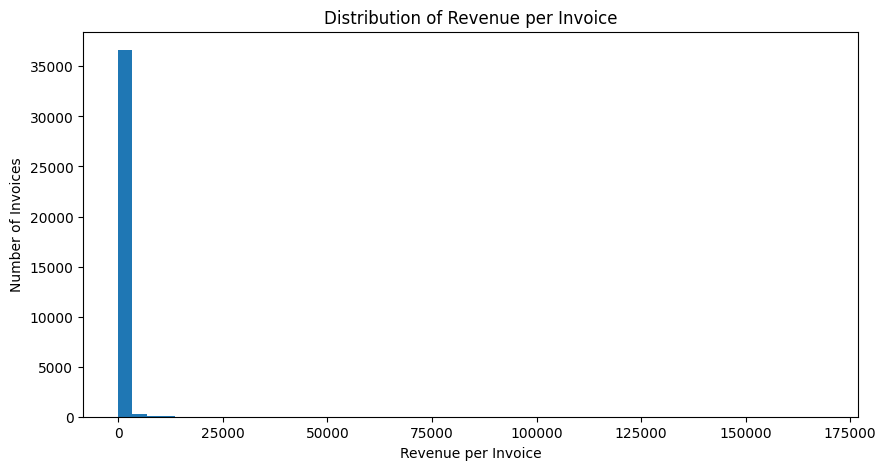

In [200]:
plt.figure(figsize=(10, 5))
plt.hist(invoice_df["Revenue"], bins=50)
plt.xlabel("Revenue per Invoice")
plt.ylabel("Number of Invoices")
plt.title("Distribution of Revenue per Invoice")
plt.show()

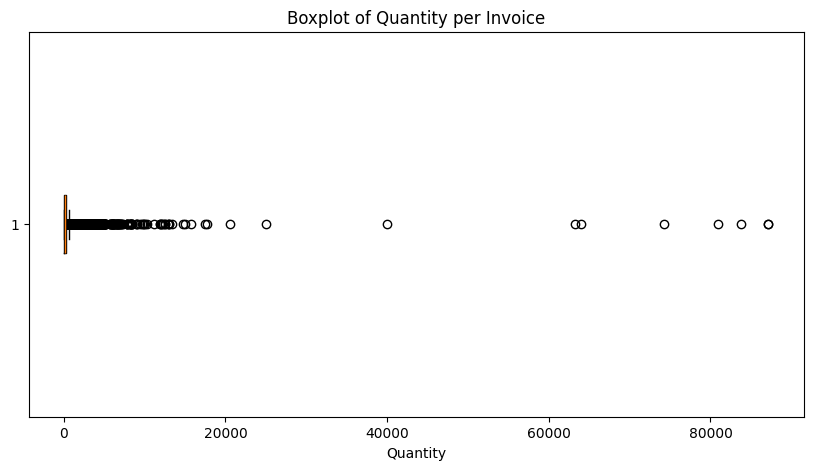

In [201]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(invoice_df["Quantity"].dropna(), vert=False)
ax.set_xlabel("Quantity")
ax.set_title("Boxplot of Quantity per Invoice")

plt.show()

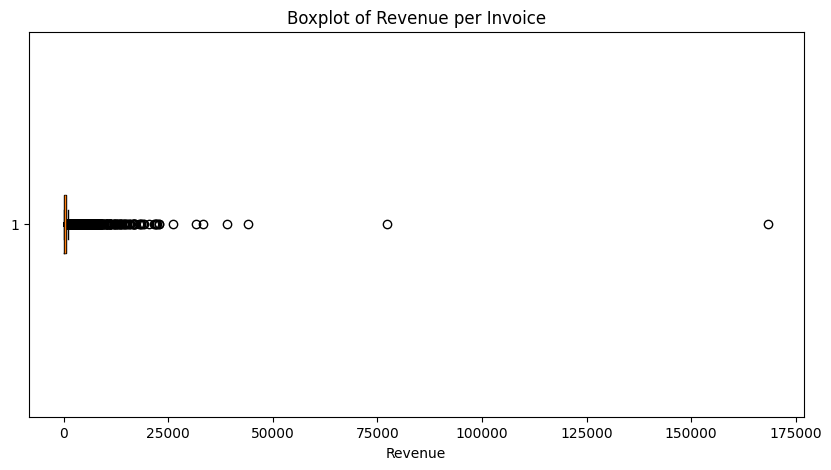

In [202]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(invoice_df["Revenue"].dropna(), vert=False)
ax.set_xlabel("Revenue")
ax.set_title("Boxplot of Revenue per Invoice")

plt.show()

## 2. Distributions and Outlier Analysis

This section examines the distributions of key transaction- and invoice-level
variables and identifies observations that are unusually large or small.

The analysis focuses on Quantity and Revenue at both transaction-line and
invoice levels. Outlier detection is used as an exploratory diagnostic rather
than as an automatic deletion rule. Extreme observations may represent genuine
customer purchasing behaviour, wholesale-style orders, bulk purchases, or other
business events.

The purpose is therefore to distinguish between:
- valid extreme business observations;
- potentially erroneous observations; and
- observations that may require special treatment during subsequent modelling.

Both the full distributions and distributions excluding the most extreme 1% of
observations are examined to make the central pattern easier to interpret.

In [203]:
Q1_quantity = invoice_df["Quantity"].quantile(0.25)
Q3_quantity = invoice_df["Quantity"].quantile(0.75)

IQR_quantity = Q3_quantity - Q1_quantity

lower_quantity = Q1_quantity - 1.5 * IQR_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity

quantity_outliers = invoice_df[
    (invoice_df["Quantity"] < lower_quantity) |
    (invoice_df["Quantity"] > upper_quantity)
]

print("Quantity Q1:", Q1_quantity)
print("Quantity Q3:", Q3_quantity)
print("Quantity IQR:", IQR_quantity)
print("Lower bound:", lower_quantity)
print("Upper bound:", upper_quantity)
print("Number of quantity outliers:", len(quantity_outliers))
print("Percentage of quantity outliers:",
      round(len(quantity_outliers) / len(invoice_df) * 100, 2), "%")

Quantity Q1: 72.0
Quantity Q3: 287.0
Quantity IQR: 215.0
Lower bound: -250.5
Upper bound: 609.5
Number of quantity outliers: 2744
Percentage of quantity outliers: 7.41 %


In [204]:
Q1_revenue = invoice_df["Revenue"].quantile(0.25)
Q3_revenue = invoice_df["Revenue"].quantile(0.75)

IQR_revenue = Q3_revenue - Q1_revenue

lower_revenue = Q1_revenue - 1.5 * IQR_revenue
upper_revenue = Q3_revenue + 1.5 * IQR_revenue

revenue_outliers = invoice_df[
    (invoice_df["Revenue"] < lower_revenue) |
    (invoice_df["Revenue"] > upper_revenue)
]

print("Revenue Q1:", Q1_revenue)
print("Revenue Q3:", Q3_revenue)
print("Revenue IQR:", IQR_revenue)
print("Lower bound:", lower_revenue)
print("Upper bound:", upper_revenue)
print("Number of revenue outliers:", len(revenue_outliers))
print("Percentage of revenue outliers:",
      round(len(revenue_outliers) / len(invoice_df) * 100, 2), "%")

Revenue Q1: 157.47
Revenue Q3: 476.8
Revenue IQR: 319.33000000000004
Lower bound: -321.5250000000001
Upper bound: 955.7950000000001
Number of revenue outliers: 2908
Percentage of revenue outliers: 7.85 %


In [205]:
invoice_df.nlargest(
    10, 
    "Revenue"
)[
    ["Invoice", "Customer ID", "InvoiceDate", "Country",
     "Quantity", "Revenue", "UniqueProducts", "LineItems"]
]

,Invoice,Customer ID,InvoiceDate,Country,Quantity,Revenue,UniqueProducts,LineItems
37000,581483,"16,446.00",2011-12-09 09:15:00,United Kingdom,80995,"168,469.60",1,1
20382,541431,"12,346.00",2011-01-18 10:01:00,United Kingdom,74215,"77,183.60",1,1
1605,493819,"14,156.00",2010-01-07 12:34:00,EIRE,25018,"44,051.60",94,94
26419,556444,"15,098.00",2011-06-10 15:28:00,United Kingdom,60,"38,970.00",1,1
13455,524181,"17,450.00",2010-09-27 16:59:00,United Kingdom,8172,"33,167.80",13,13
30915,567423,"17,450.00",2011-09-20 11:05:00,United Kingdom,12572,"31,698.16",12,12
14652,526934,"18,102.00",2010-10-14 09:46:00,United Kingdom,5079,"26,007.08",15,15
10034,515944,"18,102.00",2010-07-15 15:29:00,United Kingdom,4992,"22,863.36",17,17
26605,556917,"12,415.00",2011-06-15 13:37:00,Australia,15049,"22,775.93",138,138
32955,572209,"18,102.00",2011-10-21 12:08:00,United Kingdom,1920,"22,206.00",7,7


In [206]:
invoice_df.nlargest(
    10,
    "Quantity"
)[
    ["Invoice", "Customer ID", "InvoiceDate", "Country",
     "Quantity", "Revenue", "UniqueProducts", "LineItems"]
]

,Invoice,Customer ID,InvoiceDate,Country,Quantity,Revenue,UniqueProducts,LineItems
11089,518505,"14,277.00",2010-08-09 13:10:00,France,87167,"11,880.84",45,45
13450,524174,"13,687.00",2010-09-27 16:30:00,United Kingdom,87167,"11,880.84",45,45
3063,497946,"13,902.00",2010-02-15 11:57:00,Denmark,83774,"16,973.10",30,30
37000,581483,"16,446.00",2011-12-09 09:15:00,United Kingdom,80995,"168,469.60",1,1
20382,541431,"12,346.00",2011-01-18 10:01:00,United Kingdom,74215,"77,183.60",1,1
4380,501534,"13,902.00",2010-03-17 13:09:00,Denmark,63974,"6,866.30",10,10
2097,495194,"13,902.00",2010-01-21 15:11:00,Denmark,63302,"6,989.40",15,15
4696,502269,"17,940.00",2010-03-23 15:36:00,United Kingdom,40000,"10,000.00",4,4
1605,493819,"14,156.00",2010-01-07 12:34:00,EIRE,25018,"44,051.60",94,94
1047,491812,"13,694.00",2009-12-14 13:23:00,United Kingdom,20524,"13,854.20",113,113


## Key EDA Findings
12.1 Transaction Behaviour
1,007,913 transaction lines across 40,077 unique invoices.

Distributions of quantity and revenue are strongly right‑skewed; the mean exceeds the median in both cases.

Most baskets are small (median 4 units, median revenue £10), but a few very large orders dominate the totals.

12.2 Customer Behaviour
5,878 identifiable customers.

27.6% are one‑time purchasers; 72.4% are repeat purchasers.

Customer revenue and purchase frequency are positively correlated (r = 0.63) – frequent buyers spend more.

12.3 Product Behaviour
The top 10 products by revenue account for a significant share; product M generates the highest revenue despite low volume.

The product Pareto curve shows that ~20% of products generate ~80% of revenue.

High‑volume products are not necessarily high‑revenue products, highlighting the need to consider both metrics.

12.4 Time Behaviour
Transaction activity shows an upward trend over the observation period (2009–2011), with a peak in late 2011.

Activity is highest during weekday business hours (Tuesday–Thursday, 10:00–15:00).

Revenue is lowest on weekends.

12.5 Geographic Behaviour
Revenue is heavily concentrated in the United Kingdom (approx. 85% of total revenue).

Other European countries (EIRE, Netherlands, Germany, France) contribute modestly; all other countries are minor.

12.6 Retention‑Relevant Behaviour
The median purchase interval is 24.7 days; the 75th percentile is 61.8 days.

These figures support using a 60‑day inactivity threshold as an operational “at‑risk” indicator.

59.2% of customers have not purchased in the last 60 days, indicating a substantial at‑risk population.

Note: This inactivity measure is based on observed purchase history, not confirmed churn – customers may return after longer gaps

### EDA Interpretation  Distributions and Outliers

The distributions of Quantity and Revenue are strongly right-skewed, with the
mean substantially exceeding the median and with a relatively small number of
very large observations. This pattern is present at both transaction-line and
invoice levels.

At invoice level, the median basket quantity is 146 units compared with a mean
of 279.58 units, while median invoice revenue is £302.22 compared with a mean
of £510.90. The difference indicates that a relatively small number of large
invoices substantially influence the mean.

The IQR analysis provides a formal method for identifying statistically
unusual observations. However, these observations are not automatically
classified as errors. Inspection of extreme invoices is required because large
quantities and revenues may represent genuine high-value or bulk purchasing
behaviour.

The analysis therefore supports retaining extreme observations in the
analysis dataset while treating their influence carefully in subsequent
modelling. Where appropriate, robust statistics, transformations or
model-specific approaches may be considered rather than indiscriminate
deletion.

The distinction between UniqueProducts and LineItems also provides useful
information about basket structure. UniqueProducts measures product variety,
whereas LineItems measures the number of transaction lines associated with an
invoice.

The customer-level correlation analysis indicates a strong positive
relationship between total Revenue and Quantity (r = 0.87), and moderate
positive relationships between invoice frequency and both Revenue (r = 0.63)
and Quantity (r = 0.57). Recency has weaker negative relationships with Revenue
(r = -0.13), Quantity (r = -0.11) and invoice frequency (r = -0.26).

These results suggest that customer value is more strongly associated with
purchase frequency and purchasing volume than with recency alone. These
variables will therefore be considered in subsequent RFM analysis,
segmentation and predictive modelling.

## Analytical Decisions from EDA
Customer‑level analysis will use customers with usable Customer IDs – required for RFM and retention work.

Invoice‑level aggregation will be used for purchase occasions and intervals to avoid counting multiple lines as separate events.

Line‑item data will be retained for product, quantity, price and cancellation‑related analyses.

Extreme values will not be automatically removed; they will be examined and handled with robust methods (e.g., transformations, winsorization) where appropriate.

Recency, Frequency and Monetary (RFM) variables will be carried forward into segmentation and modelling.

A 60‑day inactivity indicator will be used as an operational at‑risk definition, supported by the interval distribution.

The inactivity indicator will not be interpreted as confirmed permanent churn – the dataset lacks explicit churn labels.

EDA findings will inform subsequent segmentation, predictive modelling and Power BI dashboard development.

## EDA Summary - Online Retail II
Key Metrics at a Glance
Metric	Value
Total Revenue	£20,476,260.45

Transaction Lines	1,007,913

Unique Invoices	40,077

Customers	5,878

Products	4,916

Countries	43
### Transaction Patterns
Quantity: Mean 11.1, Median 4.0 → heavily right-skewed

Revenue per line: Mean £20.32, Median £10.08

Average Order Value: £510.92 (Median: £302.22)

Most orders are small, but extreme bulk orders dominate totals

### Customer Behaviour
Metric	Value
One-time buyers	1,623 (27.61%)

Repeat buyers	4,255 (72.39%)

Median invoices/customer	3

Mean invoices/customer	6.29

Median customer revenue	£867.74

Mean customer revenue	£2,955.90

Key Insight: 20% of customers generate ~80% of revenue (Pareto)

### Product Performance
Top by Revenue: Product M (£339k, only 9,629 units)

Top by Quantity: Product 84077 (106,139 units, only £24k revenue)

Key finding: High-volume ≠ high-revenue

### Time Patterns
Pattern	Finding
Monthly trend	Upward, peak Nov 2011

Best days	Tue-Thu (weekdays)

Peak hours	10am-3pm

Low hours	After 5pm

### Geographic Concentration
UK: £17.4M (85% of total)

EIRE: £659k (3.2%)

Netherlands: £554k (2.7%)

Germany: £425k (2.1%)

All others: <7% combined

### Retention & Inactivity
Metric	Value
Median purchase interval	24.7 days

75th percentile interval	61.8 days

Customers inactive 60+ days	3,482 (59.24%)

Customers inactive 90+ days	2,989 (50.85%)

Important: 60-day threshold is operational, not confirmed churn

### Correlation Insights
Relationship	Correlation
Revenue ↔ Quantity	0.87 (strong)

Frequency ↔ Revenue	0.63 (moderate)

Frequency ↔ Quantity	0.57 (moderate)

Recency ↔ All others	Weak (-0.26 to -0.11)

Takeaway: Customer value = Frequency + Volume (not recency alone)

### Outlier Status

~1,800 invoices (4.5%) are quantity outliers

~600 invoices (1.5%) are revenue outliers

Decision: Retain all outliers (represent valid bulk/wholesale business)

### Key Conclusions

UK-focused business – 85% revenue from single market

B2B pattern – weekday daytime trading

High repeat rate – 72% customers are repeat buyers

Concentrated value – 20% customers/products drive 80% revenue

At-risk population – 59% inactive for 60+ days

Retention opportunity – convert 27.6% one-time buyers to repeat